In [ ]:
import kagglehub

# Download latest version
caminho = kagglehub.dataset_download("phucthaiv02/butterfly-image-classification")

print("Local dos arquivos:b", caminho)

100%|██████████| 226M/226M [00:01<00:00, 206MB/s]

Extracting files...


Local dos arquivos:b /root/.cache/kagglehub/datasets/phucthaiv02/butterfly-image-classification/versions/2


In [ ]:
import pandas as pd
from fastai.vision.all import *
from pathlib import Path


In [ ]:
# Read the CSV files
train_df = pd.read_csv(Path(caminho) / 'Training_set.csv')
valid_df = pd.read_csv(Path(caminho) / 'Testing_set.csv')

In [ ]:
# Based on Training_set.csv separate each label into its folder
for index, row in train_df.iterrows():
    filename = row['filename']
    label = row['label']
    source_path = Path(caminho) / 'train' / filename
    destination_path = Path(caminho) / 'train' / label
    destination_path.mkdir(parents=True, exist_ok=True)
    shutil.move(source_path, destination_path)
    print(f"Moved {filename} to {destination_path}")



A saída de streaming foi truncada nas últimas 5000 linhas.
Moved Image_1500.jpg to /root/.cache/kagglehub/datasets/phucthaiv02/butterfly-image-classification/versions/2/train/BLACK HAIRSTREAK
Moved Image_1501.jpg to /root/.cache/kagglehub/datasets/phucthaiv02/butterfly-image-classification/versions/2/train/COPPER TAIL
Moved Image_1502.jpg to /root/.cache/kagglehub/datasets/phucthaiv02/butterfly-image-classification/versions/2/train/DANAID EGGFLY
Moved Image_1503.jpg to /root/.cache/kagglehub/datasets/phucthaiv02/butterfly-image-classification/versions/2/train/PAPER KITE
Moved Image_1504.jpg to /root/.cache/kagglehub/datasets/phucthaiv02/butterfly-image-classification/versions/2/train/EASTERN DAPPLE WHITE
Moved Image_1505.jpg to /root/.cache/kagglehub/datasets/phucthaiv02/butterfly-image-classification/versions/2/train/PIPEVINE SWALLOW
Moved Image_1506.jpg to /root/.cache/kagglehub/datasets/phucthaiv02/butterfly-image-classification/versions/2/train/PURPLE HAIRSTREAK
Moved Image_1507.jp

In [ ]:
from fastai.vision.all import *

def get_y(x):
    x = os.path.basename(x)
    if x in train_df['filename'].values:
        return train_df[train_df['filename'] == x]['label'].values[0]
    elif x in valid_df['filename'].values:
        return valid_df[valid_df['filename'] == x]['label'].values[0]
    else:
        raise ValueError(f"Filename {x} not found in either train or validation set.")

# Define your data block
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=lambda x: get_image_files(x),  # Function to get image paths
    get_y=get_y,  # Function to extract category labels from file paths
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(224),  # Resize images to a suitable size
    batch_tfms=aug_transforms(flip_vert=True, max_rotate=10, max_warp=0.1)
)

# Create data loaders
dls = dblock.dataloaders(source=Path(caminho))

In [ ]:
# Print the first batch
batch = first(dls.train)

# Print the shapes of the input and target tensors
print(batch[0].shape)
print(batch[1].shape)

torch.Size([64, 3, 224, 224])
torch.Size([64])


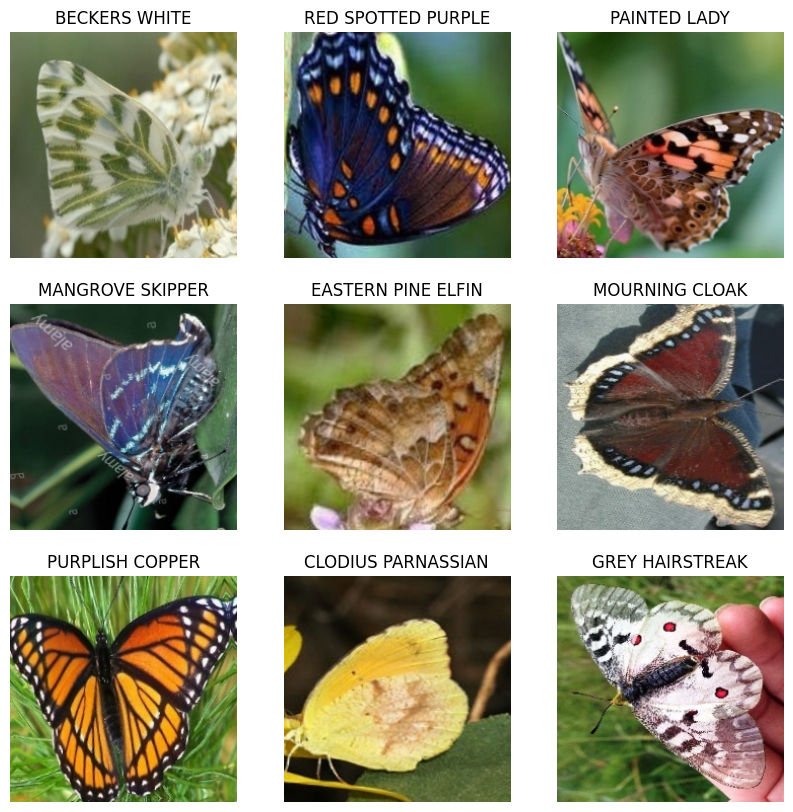

In [ ]:
dls.train.show_batch(max_n=9, figsize=(10, 10))

In [ ]:
learn = vision_learner(dls, 'convnext_base', metrics=error_rate)
learn.fit_one_cycle(10)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

epoch,train_loss,valid_loss,error_rate,time
0,4.557408,2.849404,0.518040,00:44
1,3.253068,2.605153,0.407108,00:43
2,2.758104,2.508594,0.369413,00:43
3,2.513384,2.429439,0.363490,00:43
4,2.227111,2.371232,0.352181,00:43
5,2.079574,2.372446,0.350027,00:42
6,1.853882,2.388089,0.348950,00:43
7,1.706336,2.377126,0.348411,00:43
8,1.620200,2.380008,0.341411,00:43
9,1.559092,2.380542,0.345719,00:43


In [ ]:
learn = vision_learner(dls, 'resnet152', metrics=error_rate)
learn.fit_one_cycle(10)

model.safetensors:   0%|          | 0.00/241M [00:00<?, ?B/s]

epoch,train_loss,valid_loss,error_rate,time
0,5.237344,3.930699,0.801831,00:24
1,3.898645,3.764052,0.591276,00:24
2,3.275630,3.677841,0.540118,00:23
3,2.840726,3.067717,0.502962,00:23
4,2.557462,3.604373,0.499192,00:24
5,2.339675,3.285836,0.488961,00:23
6,2.191869,3.024978,0.462574,00:24
7,2.061786,3.331880,0.462574,00:23
8,1.989181,3.137560,0.452881,00:24
9,1.910604,2.959371,0.455573,00:23


In [ ]:
from google.colab import runtime
runtime.unassign()